In [1]:
import pandas as pd

ri = pd.read_csv('RI_cleaned.csv', nrows = 50000)

drop_columns=["state", "county_name", "county_fips", "fine_grained_location"]
ri.drop(drop_columns, axis='columns', inplace=True)

ri.dropna(subset=['driver_gender'], inplace=True)

ri['is_arrested'] = ri.is_arrested.astype('bool')

combined = ri.stop_date.str.cat(ri.stop_time, sep=' ')
ri['stop_datetime'] = pd.to_datetime(combined)
ri.drop(["stop_date", "stop_time"], axis='columns', inplace=True)

ri.set_index('stop_datetime', inplace=True)

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/2576096239.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  ri = pd.read_csv('RI_cleaned.csv', nrows = 50000)


<h1><p style="text-align: center;">Datenanalyse mit Python <br>Projekt – 1</p></h1> <h1>- Polizeikontrollen im Straßenverkehr </h1>

## Zeitliche Trends bei Polizeikontrollen

Wird man zu bestimmten Tageszeiten häufiger verhaftet?  
Nehmen drogenbezogene Stopps zu?  

In diesem Kapitel beantworten Sie diese und weitere Fragen, indem Sie den Datensatz **visuell analysieren**,  
denn Diagramme helfen dabei, Trends zu erkennen, die in den Rohdaten schwer zu erkennen sind.

## 1. Berechnung der stündlichen Verhaftungsrate

Wenn ein Polizeibeamter einen Fahrer anhält, endet ein kleiner Prozentsatz dieser Stopps mit einer Verhaftung.  
Dies wird als **arrest rate** bezeichnet. In dieser Übung finden Sie heraus, ob die **arrest rate** je nach Tageszeit variiert.

Zuerst berechnen Sie die **arrest rate** über alle Stopps hinweg.  
Dann berechnen Sie die **stündliche arrest rate**, indem Sie das Attribut ``hour`` des ``index`` verwenden.  

Die Stunden reichen von ``0`` bis ``23``, wobei gilt:

``0 = Mitternacht``  
``12 = Mittag``  
``23 = 23 Uhr (11 PM)``


> Bevor Sie mit diesem Abschnitt beginnen, **wiederholen Sie die Schritte zur Datenvorbereitung aus dem ersten Kapitel.**  
Setzen Sie die Arbeit in diesem Kapitel dort fort, wo Sie das erste Kapitel beendet haben.


**ANWEISUNGEN**

*   Berechnen Sie den Mittelwert der Spalte ``is_arrested``, um die allgemeine **arrest rate** zu erhalten.
*   Gruppieren Sie nach dem Attribut ``hour`` des ``DataFrame``-Index, um die stündliche **arrest rate** zu berechnen.
*   Speichern Sie die ``Series`` mit der **hourly arrest rate** als neues Objekt ``hourly_arrest_rate``.

In [2]:
ri.head(2)

,id,location_raw,police_department,driver_gender,driver_age_raw,driver_age,driver_race_raw,driver_race,violation_raw,violation,search_conducted,search_type_raw,search_type,contraband_found,stop_outcome,is_arrested,stop_duration,out_of_state,drugs_related_stop,district
stop_datetime,,,,,,,,,,,,,,,,,,,,
2005-01-02 01:55:00,RI-2005-00001,Zone K1,600,M,1985.0,20.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone K1
2005-01-02 20:30:00,RI-2005-00002,Zone X4,500,M,1987.0,18.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,16-30 Min,False,False,Zone X4


In [3]:
ri.is_arrested.mean()

0.05182253697146428

In [4]:
type(ri.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [5]:
# Ruft nur die Stunden aus dem Index ab (datetime-Eigenschaft)
ri.index.hour

# Der Index ist ``stop_datetime``, den wir zuvor in datetime umgewandelt haben – daher können wir ``.hour`` verwenden.

Index([ 1, 20, 12,  1,  8,  8, 17, 23, 20,  3,
       ...
       22, 22, 22, 22, 22, 22, 22, 22, 23, 23],
      dtype='int32', name='stop_datetime', length=48010)

In [6]:
# Welche eindeutigen Stundenwerte enthält ri.index.hour? (Sollten 24 sein: 0–23)
ri.index.hour.unique()

Index([ 1, 20, 12,  8, 17, 23,  3,  2,  4,  5, 10, 15, 14,  9,  0, 21, 22, 13,
       16, 11,  7, 19, 18,  6],
      dtype='int32', name='stop_datetime')

In [7]:
# Anzahl der eindeutigen Stundenwerte im Index (sollte 24 ergeben)
ri.index.hour.nunique()  # Es gibt 24 eindeutige Werte

24

In [8]:
ri.index

DatetimeIndex(['2005-01-02 01:55:00', '2005-01-02 20:30:00',
               '2005-01-04 12:55:00', '2005-01-06 01:30:00',
               '2005-01-12 08:05:00', '2005-01-18 08:15:00',
               '2005-01-18 17:13:00', '2005-01-23 23:15:00',
               '2005-01-24 20:32:00', '2005-02-09 03:05:00',
               ...
               '2006-08-08 22:22:00', '2006-08-08 22:25:00',
               '2006-08-08 22:30:00', '2006-08-08 22:30:00',
               '2006-08-08 22:45:00', '2006-08-08 22:45:00',
               '2006-08-08 22:45:00', '2006-08-08 22:53:00',
               '2006-08-08 23:00:00', '2006-08-08 23:00:00'],
              dtype='datetime64[ns]', name='stop_datetime', length=48010, freq=None)

In [9]:
# Gruppiere nach Stunde des Index und berechne den Mittelwert von ``is_arrested``
# → ergibt die stündliche Verhaftungsrate
ri.groupby(ri.index.hour).is_arrested.mean()

stop_datetime
0     0.091657
1     0.113384
2     0.113103
3     0.084877
4     0.065217
5     0.037975
6     0.020573
7     0.022004
8     0.023802
9     0.031267
10    0.033094
11    0.026150
12    0.046575
13    0.035284
14    0.034194
15    0.046850
16    0.044487
17    0.054431
18    0.049796
19    0.059952
20    0.060850
21    0.115991
22    0.073970
23    0.066730
Name: is_arrested, dtype: float64

In [10]:
# Die stündliche arrest rate in einer neuen Series namens hourly_arrested_rate speichern
hourly_arrested_rate = ri.groupby(ri.index.hour).is_arrested.mean()

In [11]:

hourly_arrested_rate

stop_datetime
0     0.091657
1     0.113384
2     0.113103
3     0.084877
4     0.065217
5     0.037975
6     0.020573
7     0.022004
8     0.023802
9     0.031267
10    0.033094
11    0.026150
12    0.046575
13    0.035284
14    0.034194
15    0.046850
16    0.044487
17    0.054431
18    0.049796
19    0.059952
20    0.060850
21    0.115991
22    0.073970
23    0.066730
Name: is_arrested, dtype: float64

## 2. Visualisierung der stündlichen Verhaftungsrate

Sie erstellen ein Liniendiagramm aus dem Objekt ``hourly_arrest_rate``.  
Ein Liniendiagramm ist hier sinnvoll, da es zeigt, wie sich eine Größe im Laufe der Zeit verändert.

Diese Visualisierung kann dabei helfen, Trends zu erkennen,  
die beim Betrachten der Rohdaten nicht sofort ersichtlich waren!

**ANWEISUNGEN**

*   Importieren Sie ``matplotlib.pyplot`` mit dem Alias ``plt``.
*   Erstellen Sie ein **Liniendiagramm** von ``hourly_arrest_rate`` mit der Methode ``.plot()``.
*   Beschriften Sie die ``x-axis`` mit ``'Hour'``, die ``y-axis`` mit ``'Arrest Rate'`` und geben Sie dem Diagramm den Titel ``'Arrest Rate by Time of Day'``.
*   Zeigen Sie das Diagramm mit der Funktion ``.show()`` an.

In [12]:
import matplotlib.pyplot as plt

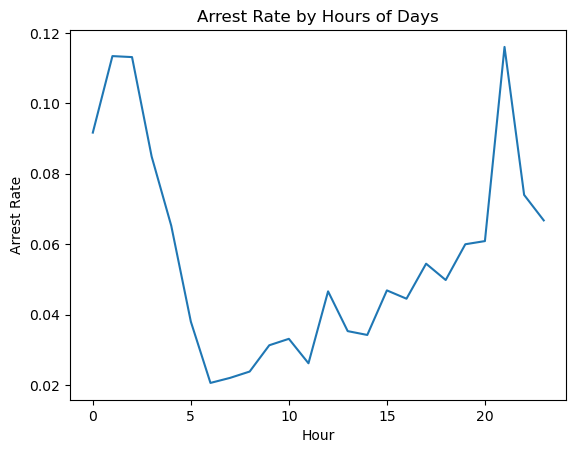

In [13]:
hourly_arrested_rate.plot()
plt.xlabel("Hour")
plt.ylabel("Arrest Rate")
plt.title("Arrest Rate by Hours of Days")

plt.show()

## 3. Visualisierung drogenbezogener Stopps

Bei einem kleinen Teil der Verkehrskontrollen werden bei der Durchsuchung Drogen im Fahrzeug gefunden.  
Sie untersuchen, ob diese **drug-related stops** im Laufe der Zeit häufiger werden.

Die boolesche Spalte ``drugs_related_stop`` zeigt an, ob bei einem bestimmten Stopp Drogen gefunden wurden.  
Sie berechnen die **annual drug rate**, indem Sie diese Spalte **resamplen**,  
und visualisieren anschließend mithilfe eines Liniendiagramms, wie sich diese Rate im Zeitverlauf verändert hat.

**ANWEISUNGEN**

*   Berechnen Sie die **annual rate** der ``drug-related stops``, indem Sie die Spalte ``drugs_related_stop`` mit der Frequenz ``'A'`` **resamplen** und den Mittelwert nehmen.
*   Speichern Sie die resultierende ``Series`` als neues Objekt ``annual_drug_rate``.
*   Erstellen Sie ein Liniendiagramm von ``annual_drug_rate`` mit der Methode ``.plot()``.
*   Zeigen Sie das Diagramm mit ``.show()`` an.

In [14]:
ri.head(2)

,id,location_raw,police_department,driver_gender,driver_age_raw,driver_age,driver_race_raw,driver_race,violation_raw,violation,search_conducted,search_type_raw,search_type,contraband_found,stop_outcome,is_arrested,stop_duration,out_of_state,drugs_related_stop,district
stop_datetime,,,,,,,,,,,,,,,,,,,,
2005-01-02 01:55:00,RI-2005-00001,Zone K1,600,M,1985.0,20.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone K1
2005-01-02 20:30:00,RI-2005-00002,Zone X4,500,M,1987.0,18.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,16-30 Min,False,False,Zone X4


Wenn wir eine vorhandene Variable haben, können wir daraus eine Spalte mit ``True``- und ``False``-Werten erstellen.

Solche booleschen Daten sind äußerst nützlich für Analysen!


In [ ]:
# ``drugs_related_stop`` ist eigentlich ein Boolean-Wert, aber .value_counts() gibt eine Series vom Typ int64 zurück
# → Das liegt daran, dass die Ausgabe (Anzahl der True/False-Werte) als Ganzzahlen gespeichert wird

ri.drugs_related_stop.value_counts()

False    47685
True       325
Name: drugs_related_stop, dtype: int64

> Ergebnis: 47685 ``False``, 325 ``True`` → also 325 ``drug-related stops``

Zeitreihen mit anderer Frequenz darstellen.

Die Methode ``resample()`` dient der Umwandlung und Gruppierung von Zeitreihendaten.  
Das Objekt muss einen datetime-ähnlichen Index besitzen  
(z. B. ``DatetimeIndex``, ``PeriodIndex`` oder ``TimedeltaIndex``),  
oder es müssen datetime-ähnliche Werte mit dem Parameter ``on`` oder ``level`` übergeben werden.


In [15]:
# 'A' steht für 'annual' (jährlich)
# Berechnet den Mittelwert von ``drugs_related_stop`` für jedes Jahr
ri.drugs_related_stop.resample("A").mean()

# → jährliche Rate der ``drug-related stops``

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/3792911786.py:3: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ri.drugs_related_stop.resample("A").mean()


stop_datetime
2005-12-31    0.008038
2006-12-31    0.006257
Freq: YE-DEC, Name: drugs_related_stop, dtype: float64

In [16]:
# jährliche ``drug-related stop``-Rate
annual_drug_rate = ri.drugs_related_stop.resample("A").mean()

# neue Series erstellt
annual_drug_rate

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/285338355.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_drug_rate = ri.drugs_related_stop.resample("A").mean()


stop_datetime
2005-12-31    0.008038
2006-12-31    0.006257
Freq: YE-DEC, Name: drugs_related_stop, dtype: float64

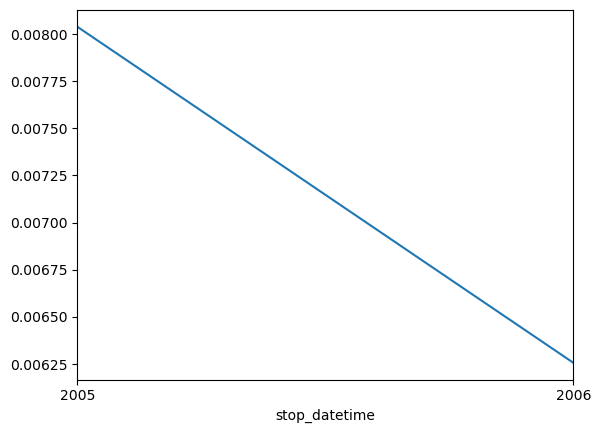

In [17]:
# Linie zeichnen für annual_drug_rate
annual_drug_rate.plot()

# Diagramm anzeigen
plt.show()

## 4. Vergleich von Drogen- und Durchsuchungsraten (wird gelöscht)


Wie Sie in der letzten Übung gesehen haben, ist die Rate der **drug-related stops** zwischen ``2005`` und ``2015`` deutlich gestiegen.  
Daraus könnte man die Hypothese ableiten, dass auch die Rate der Fahrzeugsuchen zugenommen hat –  
was zu mehr ``drug-related stops`` geführt hätte, selbst wenn nicht mehr Fahrer Drogen bei sich hatten.

Diese Hypothese können Sie testen, indem Sie die jährliche ``search rate`` berechnen  
und sie dann zusammen mit der ``annual drug rate`` visualisieren.  
Wenn die Hypothese zutrifft, sollten beide Raten im Zeitverlauf steigen.

**ANWEISUNGEN**

*   Berechnen Sie die jährliche ``search rate``, indem Sie die Spalte ``search_conducted`` **resamplen**, und speichern Sie das Ergebnis als ``annual_search_rate``.
*   Fügen Sie ``annual_drug_rate`` und ``annual_search_rate`` entlang der ``columns axis`` zusammen, und speichern Sie das Ergebnis als ``annual``.
*   Erstellen Sie Subplots der Drogen- und Suchraten aus dem ``annual``-``DataFrame``.
*   Zeigen Sie die Subplots an.

In [18]:
ri.columns

Index(['id', 'location_raw', 'police_department', 'driver_gender',
       'driver_age_raw', 'driver_age', 'driver_race_raw', 'driver_race',
       'violation_raw', 'violation', 'search_conducted', 'search_type_raw',
       'search_type', 'contraband_found', 'stop_outcome', 'is_arrested',
       'stop_duration', 'out_of_state', 'drugs_related_stop', 'district'],
      dtype='object')

In [19]:
# Zeige die ersten Werte der Spalte ``search_conducted``
ri.search_conducted.head()

stop_datetime
2005-01-02 01:55:00    False
2005-01-02 20:30:00    False
2005-01-04 12:55:00    False
2005-01-06 01:30:00    False
2005-01-12 08:05:00    False
Name: search_conducted, dtype: bool

In unseren Daten könnten fehlende Werte (``missing values``) enthalten sein – das haben wir noch nicht überprüft.  
Um auf Nummer sicher zu gehen, entfernen wir diese vorher mit der Methode ``.dropna()``.

In [20]:
# Fehlende Werte entfernen, dann Boolean in Integer umwandeln (True → 1, False → 0)
# Danach jährlich resamplen und Mittelwert berechnen
ri.search_conducted.dropna().astype("int").resample("A").mean()

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/141987782.py:3: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ri.search_conducted.dropna().astype("int").resample("A").mean()


stop_datetime
2005-12-31    0.050692
2006-12-31    0.038361
Freq: YE-DEC, Name: search_conducted, dtype: float64

In [21]:
# jährliche ``search rate`` berechnen und in ``annual_search_rate`` speichern
annual_search_rate = ri.search_conducted.dropna().astype("int").resample("A").mean()

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/1415851997.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_search_rate = ri.search_conducted.dropna().astype("int").resample("A").mean()


In [22]:
annual_search_rate

stop_datetime
2005-12-31    0.050692
2006-12-31    0.038361
Freq: YE-DEC, Name: search_conducted, dtype: float64

In [23]:
# Beide Series entlang der Spaltenachse zusammenfügen (gemeinsamer Datetime-Index)
annual = pd.concat([annual_drug_rate, annual_search_rate], axis="columns")

In [24]:
annual

,drugs_related_stop,search_conducted
stop_datetime,,
2005-12-31,0.008038,0.050692
2006-12-31,0.006257,0.038361


In [25]:
# plt.subplot(2,1,1)

# plt.subplot(2,1,2)

# Das ist ein Methodenaufruf, der die Achsen des Diagramms anpasst

Jetzt zeichne ich ein Diagramm mit der Methode ``.plot(subplots=True)``.

``.plot()``  
Erstellt Diagramme für eine ``Series`` oder ein ``DataFrame``.

    subplots : bool, Standardwert = False  
        Wenn ``True``, wird für jede Spalte ein separates Diagramm erzeugt.

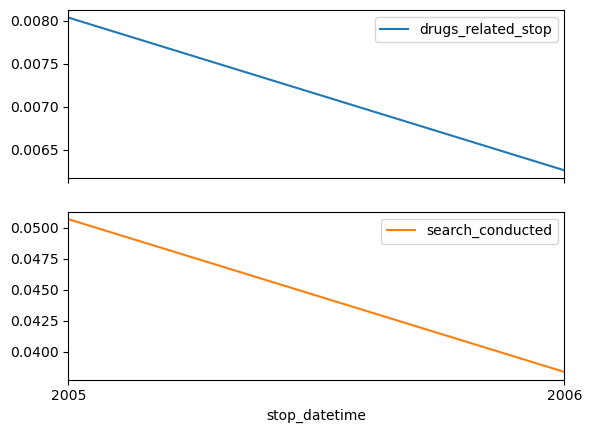

In [26]:
# Separate Diagramme für jede Spalte von ``annual``
annual.plot(subplots=True)

# Diagramme anzeigen
plt.show()


***

## 5. Zählen der Verstöße nach Bezirk

Der Bundesstaat **Rhode Island** ist in sechs Polizeibezirke unterteilt, sogenannte Zonen.  
Wie unterscheiden sich diese Zonen in Bezug auf die von der Polizei festgestellten Verstöße?

In dieser Übung erstellen Sie eine Häufigkeitstabelle, um herauszufinden,  
wie viele Verstöße jeder Art in den sechs Zonen aufgetreten sind.  
Anschließend filtern Sie die Tabelle auf die ``"K"``-Zonen,  
die Sie in der nächsten Übung näher untersuchen werden.

**ANWEISUNGEN**

*   Erstellen Sie eine ``frequency table`` aus den Spalten ``district`` und ``violation`` mit der Funktion ``pd.crosstab()``.
*   Speichern Sie die ``frequency table`` als neues Objekt ``all_zones``.
*   Wählen Sie die Zeilen ``'Zone K1'`` bis ``'Zone K3'`` aus ``all_zones`` mit dem ``.loc[]``-Accessor aus.
*   Speichern Sie die verkleinerte Tabelle als neues Objekt ``k_zones``.

In [27]:
ri.head()

,id,location_raw,police_department,driver_gender,driver_age_raw,driver_age,driver_race_raw,driver_race,violation_raw,violation,search_conducted,search_type_raw,search_type,contraband_found,stop_outcome,is_arrested,stop_duration,out_of_state,drugs_related_stop,district
stop_datetime,,,,,,,,,,,,,,,,,,,,
2005-01-02 01:55:00,RI-2005-00001,Zone K1,600,M,1985.0,20.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone K1
2005-01-02 20:30:00,RI-2005-00002,Zone X4,500,M,1987.0,18.0,W,White,Speeding,Speeding,False,NaN,NaN,False,Citation,False,16-30 Min,False,False,Zone X4
2005-01-04 12:55:00,RI-2005-00004,Zone X4,500,M,1986.0,19.0,W,White,Equipment/Inspection Violation,Equipment,False,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone X4
2005-01-06 01:30:00,RI-2005-00005,Zone X4,500,M,1978.0,27.0,B,Black,Equipment/Inspection Violation,Equipment,False,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone X4
2005-01-12 08:05:00,RI-2005-00006,Zone X1,0,M,1973.0,32.0,B,Black,Call for Service,Other,False,NaN,NaN,False,Citation,False,30+ Min,True,False,Zone X1


In [28]:
# Einen Blick auf die Spalte ``district`` werfen
ri.district.unique()

# Es gibt 6 eindeutige Werte (Zonen)

array(['Zone K1', 'Zone X4', 'Zone X1', 'Zone K3', 'Zone X3', 'Zone K2'],
      dtype=object)

In [73]:
# kategorical'a çevirirsek ona göre fonksiyon ve metodlar geleceği için bunların yararlarını görebiliyoruz.

In [29]:
# Wie oft kommt jeder ``district``-Wert vor? (ähnlich wie ein Histogramm)
ri.district.value_counts()

district
Zone K3    13554
Zone X4    10563
Zone K2     9707
Zone K1     6809
Zone X3     5460
Zone X1     1917
Name: count, dtype: int64

In [30]:
# Es wurde nach einer Häufigkeitstabelle für ``violation`` und ``district`` gefragt – also schauen wir uns nun auch ``violation`` an.
ri.violation.unique()

array(['Speeding', 'Equipment', 'Other', 'Moving violation',
       'Registration/plates'], dtype=object)

**HINWEIS: Wenn du die Häufigkeit zweier Merkmale vergleichen willst, kannst du dafür ``crosstab()`` verwenden.**

In [32]:
# ``district`` als Index, ``violation`` als Spalten – Häufigkeitstabelle erstellen
pd.crosstab(ri.district, ri.violation)

violation,Equipment,Moving violation,Other,Registration/plates,Speeding
district,,,,,
Zone K1,276,517,69,52,5895
Zone K2,422,1220,156,256,7653
Zone K3,1083,1181,247,435,10608
Zone X1,93,643,44,9,1128
Zone X3,342,741,127,102,4148
Zone X4,806,2220,249,609,6679


In [33]:
# Häufigkeitstabelle als DataFrame speichern
all_zones = pd.crosstab(ri.district, ri.violation)

# ``all_zones`` ist jetzt ein DataFrame

In [35]:
# Daraus ein neues DataFrame erstellen
k_zones = all_zones.loc["Zone K1" : "Zone K3"]

***

## 6. Visualisierung der Verstöße nach Bezirk

Nachdem Sie eine Häufigkeitstabelle für die ``"K"``-Zonen erstellt haben, visualisieren Sie die Daten,  
um besser vergleichen zu können, welche ``violations`` in den einzelnen Zonen erfasst werden.

Zuerst erstellen Sie ein **Balkendiagramm**, das sich gut eignet, da Sie kategoriale Daten vergleichen.  
Anschließend erstellen Sie ein **gestapeltes Balkendiagramm**, um eine alternative Darstellung zu erhalten.  
Welches Diagramm liefert Ihnen die besseren Erkenntnisse?


**ANWEISUNGEN 1/2**

*   Erstellen Sie ein Balkendiagramm von ``k_zones``.
*   Zeigen Sie das Diagramm an und analysieren Sie es. Was fällt Ihnen bei den einzelnen Zonen auf?

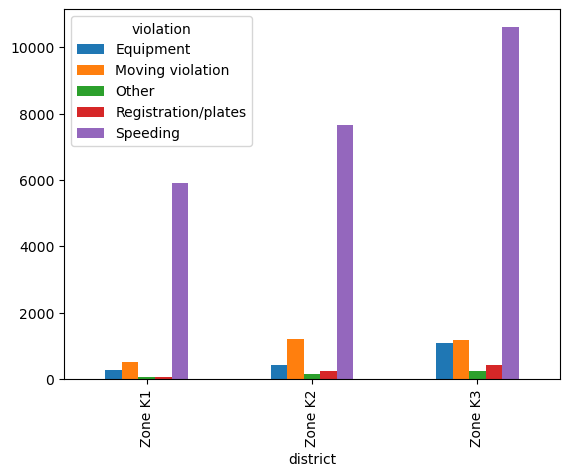

In [36]:
# Balkendiagramm für k_zones erstellen
k_zones.plot(kind="bar")

# Diagramm anzeigen
plt.show()

**ANWEISUNGEN 2/2**

*   Erstellen Sie ein gestapeltes Balkendiagramm von ``k_zones``.
*   Zeigen Sie das Diagramm an und analysieren Sie es.  
    Fällt Ihnen etwas anderes an den Daten auf als zuvor?

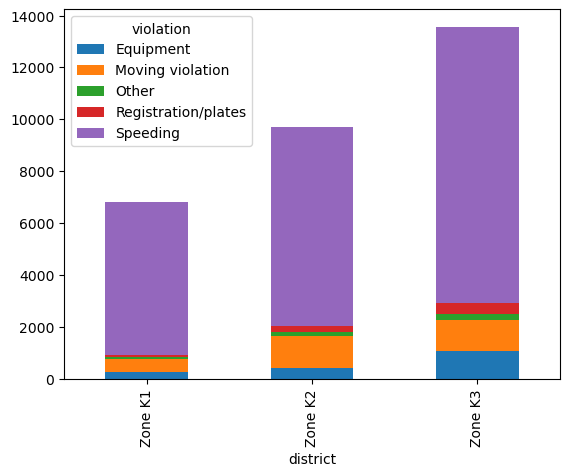

In [37]:
# Gestapeltes Balkendiagramm für k_zones
k_zones.plot(kind="bar", stacked=True)

# Diagramm anzeigen
plt.show()

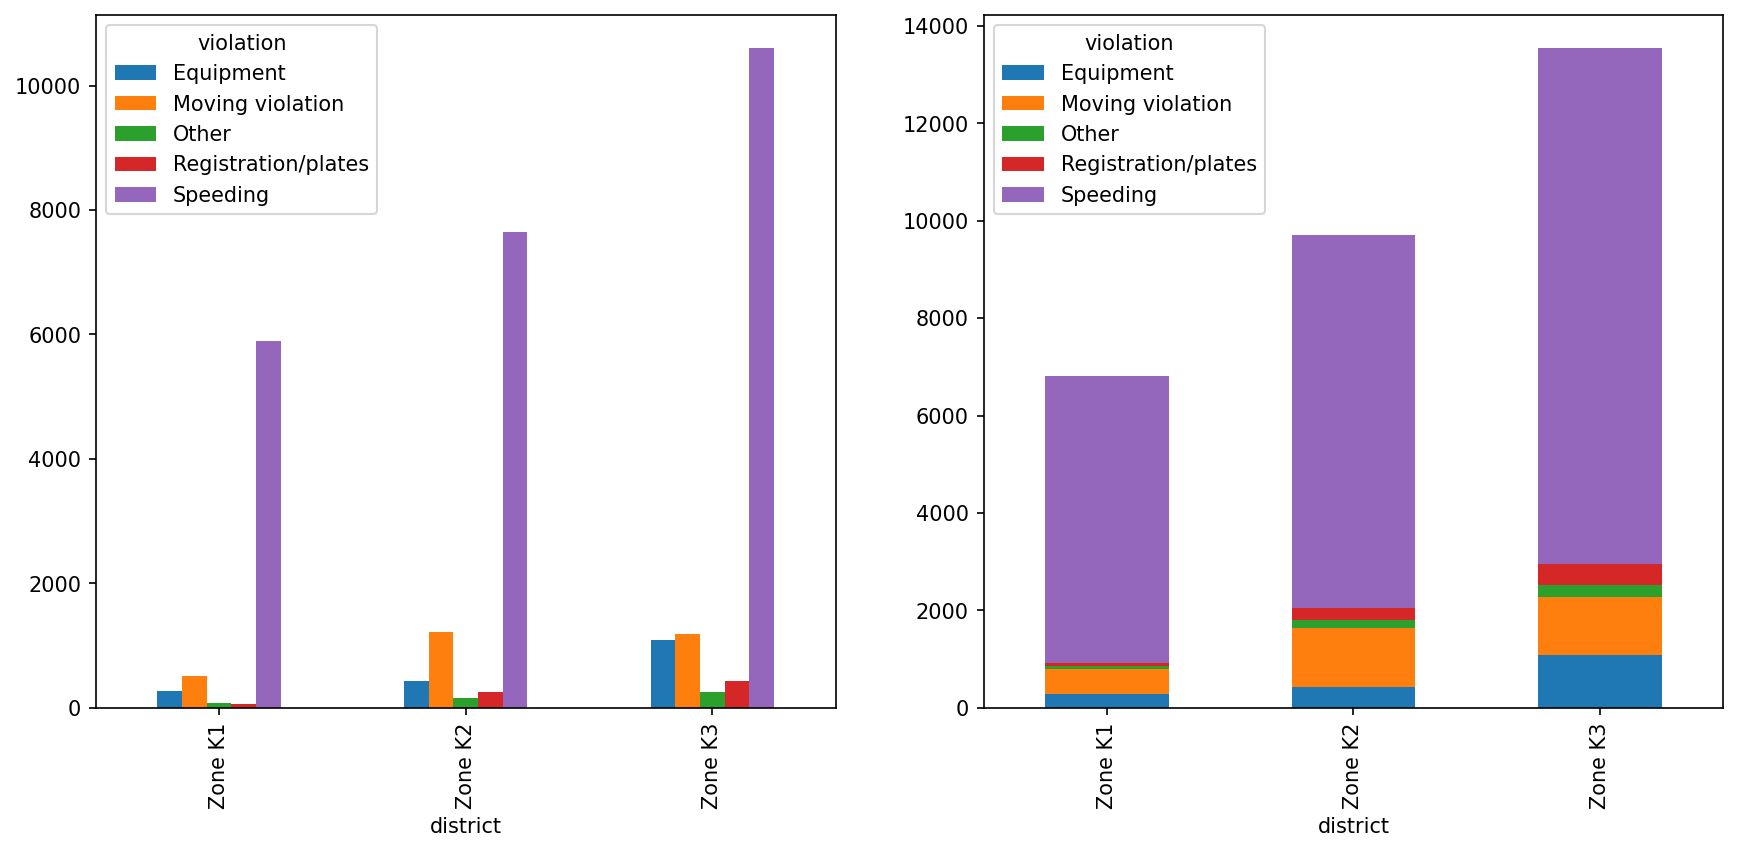

In [39]:
# Zwei Diagramme nebeneinander zeichnen – links normal, rechts gestapelt
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
k_zones.plot(kind="bar", ax=ax[0])
k_zones.plot(kind="bar", ax=ax[1], stacked=True)
plt.show()

***

## 7. Umwandlung der Stopplängen in numerische Werte

In dem Datensatz zu Verkehrskontrollen gibt die Spalte ``stop_duration`` an, wie lange ein Fahrer ungefähr von der Polizei festgehalten wurde.  
Leider sind diese Zeitangaben als ``Strings`` gespeichert, z. B. ``'0-15 Min'``.  
Wie kann man diese Daten besser analysierbar machen?

In dieser Übung wandeln Sie die **stop durations** in ``Integer``-Werte um.  
Da keine exakten Zeiten vorliegen, schätzen Sie sinnvolle Werte:

*   ``'0-15 Min'`` → ``8``
*   ``'16-30 Min'`` → ``23``
*   ``'30+ Min'`` → ``45``

**ANWEISUNGEN**

*   Geben Sie die **unique values** der Spalte ``stop_duration`` aus. (Dies wurde bereits für Sie erledigt.)
*   Erstellen Sie ein ``dictionary`` namens ``mapping``, das die ``stop_duration``-Strings den oben genannten Integer-Werten zuordnet.
*   Wandeln Sie die ``stop_duration``-Strings mithilfe des ``mapping`` in Integer um und speichern Sie das Ergebnis in einer neuen Spalte ``stop_minutes``.
*   Geben Sie die **unique values** der Spalte ``stop_minutes`` aus, um zu überprüfen, ob die Umwandlung korrekt war.

In [42]:
# Erster Blick auf die Spalte ``stop_duration``
ri.stop_duration.head()

stop_datetime
2005-01-02 01:55:00     0-15 Min
2005-01-02 20:30:00    16-30 Min
2005-01-04 12:55:00     0-15 Min
2005-01-06 01:30:00     0-15 Min
2005-01-12 08:05:00      30+ Min
Name: stop_duration, dtype: object

In [43]:
# Alle eindeutigen Werte in der Spalte ``stop_duration``
ri.stop_duration.unique()

# Es gibt auch unerwartete Werte wie "3" und "1" – diese sollten vorher entfernt werden.

array(['0-15 Min', '16-30 Min', '30+ Min'], dtype=object)

In [44]:
ri = pd.read_csv("RI_cleaned.csv", nrows = 50000)

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_9434/3178778489.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  ri = pd.read_csv("RI_cleaned.csv", nrows = 50000)


Da jedoch einige Werte aus vorherigen Zellen später noch benötigt werden, wäre es besser, 
diese Zeile ganz oben einzufügen und anschließend „Run all cells“ auszuführen, um Fehler zu vermeiden.

In [45]:
ri.stop_duration.head()

0     0-15 Min
1    16-30 Min
2          NaN
3     0-15 Min
4     0-15 Min
Name: stop_duration, dtype: object

In [46]:
# Überprüfung der eindeutigen Werte in ``stop_duration``
ri.stop_duration.unique()

# Jetzt sehe ich, dass die Werte "2" und "1" nicht mehr enthalten sind (im Datenausschnitt mit 50.000 Zeilen)

array(['0-15 Min', '16-30 Min', nan, '30+ Min'], dtype=object)

In [48]:
# Dictionary zur Umwandlung von Zeitangaben
mapping = {"0-15 Min": 8, "16-30 Min": 23, "30+ Min": 45}

In [49]:
# mapping auf stop_duration anwenden und neue Spalte stop_minutes erstellen
ri["stop_minutes"] = ri.stop_duration.map(mapping)

In [51]:
# andere Möglichkeit, die Werte zu ersetzen
 
# ri["stop_minutes"] = ri["stop_duration"].replace(mapping).astype("int")

In [52]:
ri.stop_minutes.unique()

array([ 8., 23., nan, 45.])

In [53]:
ri.head(3)

,id,state,stop_date,stop_time,location_raw,county_name,county_fips,fine_grained_location,police_department,driver_gender,...,search_type_raw,search_type,contraband_found,stop_outcome,is_arrested,stop_duration,out_of_state,drugs_related_stop,district,stop_minutes
0,RI-2005-00001,RI,2005-01-02,01:55,Zone K1,NaN,NaN,NaN,600,M,...,NaN,NaN,False,Citation,False,0-15 Min,False,False,Zone K1,8.0
1,RI-2005-00002,RI,2005-01-02,20:30,Zone X4,NaN,NaN,NaN,500,M,...,NaN,NaN,False,Citation,False,16-30 Min,False,False,Zone X4,23.0
2,RI-2005-00003,RI,2005-01-04,11:30,Zone X1,NaN,NaN,NaN,0,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,False,Zone X1,NaN


***

## 8. Visualisierung der Stopplänge

Wenn man wegen eines bestimmten Verstoßes angehalten wird – wie lange kann man erwarten, festgehalten zu werden?

In dieser Übung visualisieren Sie die **durchschnittliche Dauer**,  
für die Fahrer je nach Art des **Verstoßes** angehalten werden.  

Anstelle der Spalte ``violation`` verwenden Sie diesmal ``violation_raw``,  
da sie genauere Beschreibungen der Verstöße enthält.

**ANWEISUNGEN**

*   Berechnen Sie für jeden Wert in der Spalte ``violation_raw`` die **durchschnittliche Anzahl** der ``stop_minutes``, die ein Fahrer festgehalten wurde.
*   Speichern Sie die resultierende ``Series`` als neues Objekt ``stop_length``.
*   Sortieren Sie ``stop_length`` nach den Werten und visualisieren Sie sie als **horizontales Balkendiagramm**.
*   Zeigen Sie das Diagramm an.

In [54]:
ri.violation_raw.unique()

array(['Speeding', nan, 'Equipment/Inspection Violation',
       'Call for Service', 'Other Traffic Violation',
       'Registration Violation', 'Violation of City/Town Ordinance',
       'Special Detail/Directed Patrol', 'APB',
       'Motorist Assist/Courtesy', 'Suspicious Person', 'Warrant'],
      dtype=object)

In [55]:
# Für jeden Wert in ``violation_raw`` den Durchschnitt der ``stop_minutes`` berechnen
ri.groupby("violation_raw").stop_minutes.mean()

violation_raw
APB                                 28.078431
Call for Service                    27.674370
Equipment/Inspection Violation      13.668101
Motorist Assist/Courtesy            15.528409
Other Traffic Violation             14.207298
Registration Violation              17.304170
Special Detail/Directed Patrol      30.902778
Speeding                             9.707133
Suspicious Person                   21.821429
Violation of City/Town Ordinance    11.153846
Warrant                             29.666667
Name: stop_minutes, dtype: float64

In [56]:
# Durchschnittliche Stopdauer je ``violation_raw`` berechnen und in ``stop_length`` speichern
stop_length = ri.groupby("violation_raw").stop_minutes.mean()

stop_length  # Werte anzeigen

violation_raw
APB                                 28.078431
Call for Service                    27.674370
Equipment/Inspection Violation      13.668101
Motorist Assist/Courtesy            15.528409
Other Traffic Violation             14.207298
Registration Violation              17.304170
Special Detail/Directed Patrol      30.902778
Speeding                             9.707133
Suspicious Person                   21.821429
Violation of City/Town Ordinance    11.153846
Warrant                             29.666667
Name: stop_minutes, dtype: float64

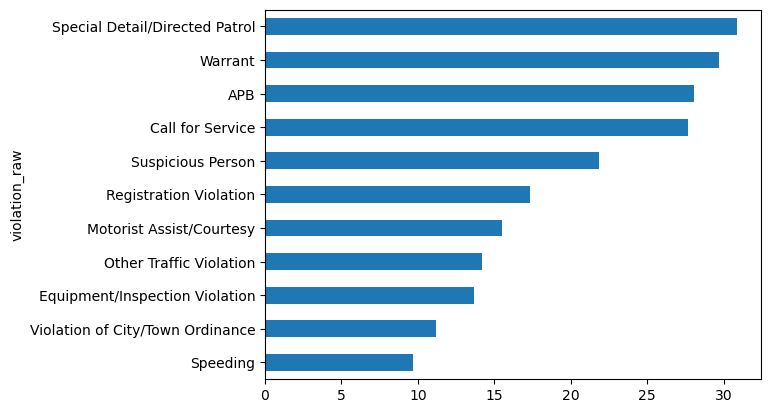

In [57]:
# Werte sortieren und als horizontales Balkendiagramm darstellen
stop_length.sort_values().plot(kind="barh")

# Diagramm anzeigen
plt.show()

### Fazit

In diesem Projekt wurden Verkehrskontroll-Daten aus Rhode Island mithilfe von Python analysiert.  
Dabei wurden wichtige Fragen zu Durchsuchungen, Verhaftungen und Verstoßarten in Abhängigkeit von Geschlecht, Uhrzeit und Region untersucht.

Durch Visualisierungen und gruppierte Auswertungen konnten klare Muster erkannt werden –  
z. B. Unterschiede in der Behandlung nach Geschlecht oder bei bestimmten Verstößen.

Diese Analyse zeigt, wie aussagekräftig strukturierte Daten sein können, wenn sie systematisch ausgewertet werden.
